# M&A Due Diligence RL Training — 3-Phase Pipeline

| Phase | Purpose | Typical Runtime |
|-------|---------|-------------|
| **1. SFT Warm-up** | Teach JSON output format | ~5 min |
| **2. Lightweight GRPO** | Test full RL loop (10 steps) | ~10 min |
| **3. Full GRPO** | Actual training → curves | ~45-90 min |

> Recommended GPU: A100 for Phase 3 heavy runs. `load_in_4bit=True` can still be used for memory safety.

In [2]:
# Cell 1: Install
!pip install -q 'unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git'
!pip install -q trl datasets httpx fastapi uvicorn slowapi matplotlib pydantic
import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU — switch runtime!')

CUDA available: True
GPU: NVIDIA A100-SXM4-80GB


In [3]:
# Cell 2: Setup — clone repo and find project root
import os, sys, glob

# Uncomment ONE of these:
# Option A: clone from GitHub
!git clone https://github.com/NJVinay/openenv_ma_analyzer.git

# Option B: upload zip via Colab file panel, then:
# import zipfile; zipfile.ZipFile('output.zip').extractall('.')

# Auto-detect project root: find the directory that contains server/
def find_project_root(start='.', max_depth=4):
    # Check current dir first
    if os.path.isdir(os.path.join(start, 'server')):
        return os.path.abspath(start)
    # Search subdirs
    for depth in range(1, max_depth + 1):
        pattern = os.path.join(start, *(['*'] * depth), 'server')
        for match in glob.glob(pattern):
            if os.path.isdir(match):
                return os.path.abspath(os.path.dirname(match))
    return os.path.abspath(start)

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

# Verify critical dirs exist
for d in ['server', 'security', 'training']:
    assert os.path.isdir(d), f'Missing {d}/ in {PROJECT_ROOT}'

print(f'Project root: {PROJECT_ROOT}')
print(f'Files: {sorted(os.listdir("."))}')

Cloning into 'openenv_ma_analyzer'...
remote: Enumerating objects: 148, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 148 (delta 56), reused 129 (delta 37), pack-reused 0 (from 0)
Receiving objects: 100% (148/148), 203.80 KiB | 33.97 MiB/s, done.
Resolving deltas: 100% (56/56), done.
Project root: /app/training/openenv_ma_analyzer
Files: ['.git', 'Dockerfile', 'README.md', '__init__.py', '__pycache__', 'blogpost.md', 'client.py', 'inference.py', 'long_horizon_architecture.md', 'loss_curve.png', 'models.py', 'openenv.yaml', 'pyproject.toml', 'requirements.txt', 'reward_curve.png', 'security', 'server', 'smoke_test.py', 'training']


In [ ]:
# Cell 3: Start environment server
import subprocess, time, httpx, sys, tempfile, os

# Capture stderr so server import errors are visible
_server_log = os.path.join(tempfile.gettempdir(), 'ma_server.log')
_server_logf = open(_server_log, 'w')

# CRITICAL: pass cwd + PYTHONPATH so the subprocess can find server/
_env = {**os.environ, 'PYTHONPATH': PROJECT_ROOT}
server_proc = subprocess.Popen(
    [sys.executable, '-m', 'uvicorn', 'server.app:app',
     '--host', '0.0.0.0', '--port', '7860'],
    stdout=_server_logf, stderr=_server_logf,
    cwd=PROJECT_ROOT,
    env=_env,
)
time.sleep(5)

try:
    r = httpx.get('http://localhost:7860/health', timeout=10)
    assert r.status_code == 200
    print('Server healthy:', r.json())
except Exception as e:
    _server_logf.flush()
    print(f'Server failed to start: {e}')
    print('--- Server log (last 50 lines) ---')
    with open(_server_log) as f:
        lines = f.readlines()
        for line in lines[-50:]:
            print(line, end='')
    print('--- End server log ---')
    raise

Server healthy: {'status': 'ok'}


In [8]:
# Cell 4: Load Qwen2.5-7B with Unsloth + LoRA
import os, importlib.util
# 1. Silence Unsloth's bugged version checker
os.environ["UNSLOTH_SKIP_TORCHVISION_CHECK"] = "1"
# 2. Blindfold the system so it skips the broken torchvision C++ extension
orig_find_spec = importlib.util.find_spec
def patch_find_spec(name, package=None):
    if name == 'torchvision': return None
    return orig_find_spec(name, package)
importlib.util.find_spec = patch_find_spec

#Load Unsloth
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='unsloth/Qwen2.5-7B-Instruct',  # Upgraded to 7B for A100 Heavy Run
    max_seq_length=4096,
    load_in_4bit=True,
    dtype=None,
)

model = FastLanguageModel.get_peft_model(
    model, r=16, lora_alpha=16,
    target_modules=['q_proj','k_proj','v_proj','o_proj',
                    'gate_proj','up_proj','down_proj'],
    lora_dropout=0.0, bias='none',
    use_gradient_checkpointing='unsloth',
    random_state=42,
)
print('Model on device:', next(model.parameters()).device)
print('LoRA applied successfully')

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/home/appuser/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights: 100%|██████████| 339/339 [00:01<00:00, 315.07it/s]


unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Model on device: cuda:0
LoRA applied successfully


---
## Phase 1: SFT Warm-up
Teaches JSON format on 20 curated M&A examples.

In [9]:
# Cell 5: SFT warm-up (portable defaults, SFTConfig fallback)
# SFTConfig requires trl>=0.8.0 — use TrainingArguments as safe fallback
try:
    from trl import SFTTrainer, SFTConfig as _SFTArgs
    _sft_extra = dict(max_seq_length=2048, dataset_text_field='text')
    _sft_trainer_extra = {}
    print('Using SFTConfig')
except ImportError:
    from trl import SFTTrainer
    from transformers import TrainingArguments as _SFTArgs
    _sft_extra = {}
    _sft_trainer_extra = dict(max_seq_length=2048, dataset_text_field='text')
    print('Using TrainingArguments fallback')

from datasets import Dataset
from training.sft_data import SFT_EXAMPLES

MA_SYSTEM_PROMPT = (
    'You are an expert M&A due diligence analyst.\n'
    'You review NDAs, Letters of Intent, Share Purchase Agreements,\n'
    'and Representations & Warranties to identify risk clauses.\n'
    'Before outputting JSON, you MUST write a highly detailed <think>...</think> block.\n'
    'In your think block, explore legal precedents, jurisdiction risks, counter-arguments, and clause interactions.\n'
    'After thinking deeply, output ONLY the JSON format specified in the task prompt.\n'
)

def format_prompt(task_prompt, deal_excerpt):
    return (f'<|system|>\n{MA_SYSTEM_PROMPT}\n'
            f'<|user|>\n{task_prompt}\n\nDocument:\n{deal_excerpt}\n'
            f'<|assistant|>\n')

def fmt_sft(ex):
    return {'text': f'<|system|>\n{MA_SYSTEM_PROMPT}\n<|user|>\n{ex["prompt"]}\n<|assistant|>\n{ex["completion"]}'}

sft_dataset = Dataset.from_list(SFT_EXAMPLES).map(fmt_sft)

sft_args = _SFTArgs(
    output_dir='./sft-checkpoint',
    num_train_epochs=8,  # Increased from 3 to 8 for better formatting compliance
    per_device_train_batch_size=1,  # Conservative SFT batch for portability
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    logging_steps=5,
    save_steps=999,
    report_to='none',
    **_sft_extra,
)

sft_trainer = SFTTrainer(
    model=model, tokenizer=tokenizer,
    train_dataset=sft_dataset, args=sft_args,
    **_sft_trainer_extra,
)
print(f'SFT: {len(sft_dataset)} examples x8 epochs')
sft_trainer.train()
sft_log = sft_trainer.state.log_history
print('Phase 1 complete!')

Using SFTConfig


Map: 100%|██████████| 19/19 [00:00<00:00, 4934.78 examples/s]
num_proc must be <= 19. Reducing num_proc to 19 for dataset of size 19.
[datasets.arrow_dataset|WARNING]num_proc must be <= 19. Reducing num_proc to 19 for dataset of size 19.
Unsloth: Tokenizing ["prompt"+"completion"] (num_proc=19): 100%|██████████| 19/19 [00:34<00:00,  1.83s/ examples]
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
SFT: 19 examples x8 epochs


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19 | Num Epochs = 8 | Total steps = 40
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,2.020269
10,1.446898
15,0.996305
20,0.644144
25,0.399067
30,0.213928
35,0.102800
40,0.056043


Unsloth: Restored added_tokens_decoder metadata in ./sft-checkpoint/checkpoint-40/tokenizer_config.json.


Phase 1 complete!


In [ ]:
# Cell 6: Verify SFT — check JSON compliance
import json, torch
from client import MADueDiligenceClient
from models import Action

env = MADueDiligenceClient(base_url='http://localhost:7860')
FastLanguageModel.for_inference(model)

json_ok = 0
for i in range(5):
    obs = env.reset(seed=i)
    inputs = tokenizer(format_prompt(obs.task_prompt, obs.deal_excerpt),
                       return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=2048,
                             do_sample=True, temperature=0.7)
    text = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()
    try:
        # Robust JSON parsing: strip markdown code blocks if present
        clean_text = text
        if '```json' in clean_text:
            clean_text = clean_text.split('```json')[1]
        if '```' in clean_text:
            clean_text = clean_text.split('```')[0]
        clean_text = clean_text.strip()
        
        parsed = json.loads(clean_text)
        json_ok += 1
        print(f'[{i}] OK keys={list(parsed.keys())}')
    except json.JSONDecodeError:
        print(f'[{i}] BAD: {text[:100]}...')

print(f'JSON compliance: {json_ok}/5')
assert json_ok >= 2, 'Too few valid JSON outputs — re-run SFT with more epochs'
FastLanguageModel.for_training(model)

Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both

[0] OK keys=['clause_type', 'reason']


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] OK keys=['clause_type', 'reason']


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[2] OK keys=['clause_type', 'reason']


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] OK keys=['clause_type', 'reason']
[4] OK keys=['clause_type', 'reason']
JSON compliance: 5/5


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151665)
        (layers): ModuleList(
          (0-1): 2 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
 

---
## Phase 2: Lightweight GRPO (10-step bug catcher)
Validates the full loop before committing to a long run.

In [11]:
# Cell 7: Reward function
import json, traceback

def ma_reward_func(completions, **kwargs):
    """Called by GRPOTrainer. Sends each completion to the M&A env."""
    rewards = []
    for completion in completions:
        try:
            text = completion if isinstance(completion, str) else str(completion)
            if '<|assistant|>' in text:
                text = text.split('<|assistant|>')[-1].strip()
            # Auto-detect action type from JSON keys
            action_type = 'identify'
            try:
                # Robust JSON parsing
                clean_text = text
                if '```json' in clean_text:
                    clean_text = clean_text.split('```json')[1]
                if '```' in clean_text:
                    clean_text = clean_text.split('```')[0]
                clean_text = clean_text.strip()
                
                p = json.loads(clean_text)
                if 'risk_level' in p: action_type = 'assess'
                elif 'rewritten_clause' in p: action_type = 'rewrite'
            except Exception: pass
            # Add a reward bonus for Long Horizon thinking
            bonus = 0.0
            if '<think>' in text and '</think>' in text:
                think_content = text.split('<think>')[1].split('</think>')[0]
                if len(think_content.strip()) > 500: bonus += 0.2
            
            # Bypass HTTP rate limits for high-speed A100 training
            from server.environment import MADueDiligenceEnvironment
            local_reward_env = MADueDiligenceEnvironment()
            obs = local_reward_env.reset()
            obs2 = local_reward_env.step(Action(agent_output=text, action_type=action_type))
            base_reward = float(obs2.reward or 0.0)
            # Only award thinking bonus if the JSON output was valid and correct
            rewards.append(base_reward + (bonus if base_reward > 0 else 0.0))
        except Exception as e:
            print(f'Reward error: {e}')
            rewards.append(0.0)
    return rewards

print('Reward function ready')

Reward function ready


In [12]:
# Cell 8: Phase 2 — 10-step GRPO test
from trl import GRPOConfig, GRPOTrainer
from datasets import Dataset
import inspect

obs0 = env.reset(seed=0)
test_dataset = Dataset.from_dict(
    {'prompt': [format_prompt(obs0.task_prompt, obs0.deal_excerpt)] * 10}
)

test_cfg = GRPOConfig(
    output_dir='./grpo-test',
    max_steps=10,
    learning_rate=5e-6,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=2,
    num_generations=2,
    max_completion_length=2048,
    logging_steps=1,
    report_to='none',
)

# TRL API varies across versions — detect the correct kwarg name
_grpo_params = inspect.signature(GRPOTrainer.__init__).parameters
_reward_kwargs = {}
if 'reward_funcs' in _grpo_params:
    _reward_kwargs['reward_funcs'] = [ma_reward_func]
    print('TRL API: using reward_funcs (list)')
elif 'reward_func' in _grpo_params:
    _reward_kwargs['reward_func'] = ma_reward_func
    print('TRL API: using reward_func (singular)')
elif 'reward_fn' in _grpo_params:
    _reward_kwargs['reward_fn'] = ma_reward_func
    print('TRL API: using reward_fn')
else:
    # Fallback: try the most common
    _reward_kwargs['reward_funcs'] = [ma_reward_func]
    print('TRL API: defaulting to reward_funcs (list)')

test_trainer = GRPOTrainer(
    model=model, tokenizer=tokenizer,
    train_dataset=test_dataset, args=test_cfg,
    **_reward_kwargs,
)
print('Phase 2: 10-step test...')
try:
    test_trainer.train()
    print('Phase 2 PASSED')
    phase2_ok = True
except Exception as e:
    traceback.print_exc()
    phase2_ok = False
    print('Phase 2 FAILED — fix before Phase 3!')

TRL API: using reward_funcs (list)
Phase 2: 10-step test...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10 | Num Epochs = 1 | Total steps = 10
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 2 x 1) = 2
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
Passing `generation_config` together with generation-related arguments=({'disable_compile', 'cache_implementation', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:7

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / ma_reward_func / mean,rewards / ma_reward_func / std
1,0.000855,0.150000,0.212132,73.500000,71.000000,76.000000,0.000000,73.500000,71.000000,76.000000,0.855272,0.150000,0.212132
2,0.001121,0.000000,0.000000,72.000000,67.000000,77.000000,0.000000,72.000000,67.000000,77.000000,1.120537,0.000000,0.000000
3,0.001116,0.150000,0.212132,82.500000,80.000000,85.000000,0.000000,82.500000,80.000000,85.000000,1.116082,0.150000,0.212132
4,0.000964,0.500000,0.707107,92.000000,72.000000,112.000000,0.000000,92.000000,72.000000,112.000000,0.964085,0.500000,0.707107
5,0.001157,0.000000,0.000000,71.500000,50.000000,93.000000,0.000000,71.500000,50.000000,93.000000,1.156517,0.000000,0.000000
6,0.001462,0.150000,0.212132,78.000000,77.000000,79.000000,0.000000,78.000000,77.000000,79.000000,1.461860,0.150000,0.212132
7,0.000951,0.500000,0.707107,90.000000,81.000000,99.000000,0.000000,90.000000,81.000000,99.000000,0.951492,0.500000,0.707107
8,0.000860,0.000000,0.000000,76.500000,73.000000,80.000000,0.000000,76.500000,73.000000,80.000000,0.860180,0.000000,0.000000
9,0.000873,0.000000,0.000000,144.500000,112.000000,177.000000,0.000000,144.500000,112.000000,177.000000,0.873144,0.000000,0.000000
10,0.001115,0.000000,0.000000,76.500000,75.000000,78.000000,0.000000,76.500000,75.000000,78.000000,1.115180,0.000000,0.000000


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both

Phase 2 PASSED


---
## Phase 3: Full GRPO Training
Only runs if Phase 2 passed. Produces reward + loss curves.

In [13]:
# Cell 9: Full GRPO
assert phase2_ok, 'Phase 2 failed — fix bugs first!'

# Build diverse prompts bypassing the HTTP rate limiter (slowapi) by using the python class directly
from server.environment import MADueDiligenceEnvironment
local_env = MADueDiligenceEnvironment()
full_prompts = []
for i in range(300):  # Expanded to 500 prompts for the heavy run
    obs = local_env.reset(seed=i)
    full_prompts.append(format_prompt(obs.task_prompt, obs.deal_excerpt))

full_dataset = Dataset.from_dict({'prompt': full_prompts})

# A100 Optimized GRPO Config
full_cfg = GRPOConfig(
    output_dir='./ma-rl-checkpoints',
    num_train_epochs=2,  # Two epochs for deeper policy refinement
    learning_rate=5e-6,
    per_device_train_batch_size=2,  # Increased for A100
    gradient_accumulation_steps=4,
    num_generations=8,  # Improved exploration/KL tradeoff
    max_prompt_length=1024, #Protection against sequential length errors
    max_completion_length=2048,
    logging_steps=5,
    save_steps=25,
    report_to='none',
)
# Reuse the same reward kwarg detected in Phase 2
full_trainer = GRPOTrainer(
    model=model, tokenizer=tokenizer,
    train_dataset=full_dataset, args=full_cfg,
    **_reward_kwargs,
)
print('Phase 3: Full GRPO starting...')
full_trainer.train()
print('Phase 3 complete!')

Phase 3: Full GRPO starting...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 300 | Num Epochs = 2 | Total steps = 600
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/app

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / ma_reward_func / mean,rewards / ma_reward_func / std
5,-0.010245,0.212500,0.391598,103.800000,67.200000,209.200000,0.000000,103.800000,67.200000,209.200000,0.844621,0.212500,0.391598
10,0.011872,0.235000,0.387435,79.225000,62.400000,95.800000,0.000000,79.225000,62.400000,95.800000,0.969207,0.235000,0.387435
15,0.009979,0.202500,0.336992,75.200000,58.800000,93.000000,0.000000,75.200000,58.800000,93.000000,0.971974,0.202500,0.336992
20,0.044837,0.145000,0.286572,109.150000,66.400000,334.200000,0.000000,109.150000,66.400000,334.200000,0.910128,0.145000,0.286572
25,-0.008907,0.237500,0.354112,74.250000,58.200000,95.000000,0.000000,74.250000,58.200000,95.000000,0.995544,0.237500,0.354112
30,0.011324,0.147500,0.326230,80.575000,60.000000,111.000000,0.000000,80.575000,60.000000,111.000000,0.972658,0.147500,0.326230
35,0.019928,0.250000,0.367973,85.125000,67.800000,117.800000,0.000000,85.125000,67.800000,117.800000,0.991313,0.250000,0.367973
40,0.056834,0.197500,0.354759,134.500000,71.000000,504.000000,0.025000,85.585715,71.000000,117.600000,0.894048,0.197500,0.354759
45,-0.028311,0.195000,0.311063,86.025000,62.600000,161.200000,0.000000,86.025000,62.600000,161.200000,0.937903,0.195000,0.311063
50,0.040438,0.155000,0.323617,105.025000,72.200000,218.800000,0.000000,105.025000,72.200000,218.800000,0.902736,0.155000,0.323617


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both

Phase 3 complete!


In [14]:
# Cell 10: Extract metrics (handles all TRL key variants)
log = full_trainer.state.log_history
print('All logged keys:', set(k for x in log for k in x))

def extract(entries, keys):
    for k in keys:
        s = [x['step'] for x in entries if k in x]
        v = [x[k] for x in entries if k in x]
        if s:
            print(f'  key={k!r} ({len(s)} pts)')
            return s, v
    print(f'  Not found among: {keys}')
    return [], []

reward_steps, reward_vals = extract(log,
    ['reward', 'rewards/mean', 'reward_mean', 'train/reward', 'rewards'])
loss_steps, loss_vals = extract(log,
    ['loss', 'train/loss', 'train_loss'])
mini_log = test_trainer.state.log_history
mini_reward_steps, mini_reward_vals = extract(mini_log,
    ['reward', 'rewards/mean', 'reward_mean', 'train/reward', 'rewards'])
sft_steps = [x.get('step', i) for i, x in enumerate(sft_log) if 'loss' in x]
sft_loss_vals = [x['loss'] for x in sft_log if 'loss' in x]
print(f'Heavy RL rewards: {len(reward_steps)} pts | Heavy RL loss: {len(loss_steps)} pts')
print(f'Mini RL rewards: {len(mini_reward_steps)} pts | SFT loss: {len(sft_steps)} pts')

All logged keys: {'clip_ratio/high_mean', 'total_flos', 'num_tokens', 'clip_ratio/region_mean', 'rewards/ma_reward_func/mean', 'epoch', 'completions/min_terminated_length', 'clip_ratio/high_max', 'completion_length', 'train_runtime', 'clip_ratio/low_min', 'completions/mean_length', 'clip_ratio/low_mean', 'train_loss', 'completions/max_terminated_length', 'step', 'completions/clipped_ratio', 'train_steps_per_second', 'completions/mean_terminated_length', 'kl', 'reward_std', 'train_samples_per_second', 'frac_reward_zero_std', 'loss', 'grad_norm', 'reward', 'completions/max_length', 'learning_rate', 'completions/min_length', 'rewards/ma_reward_func/std'}
  key='reward' (120 pts)
  key='loss' (120 pts)
  key='reward' (10 pts)
Heavy RL rewards: 120 pts | Heavy RL loss: 120 pts
Mini RL rewards: 10 pts | SFT loss: 8 pts


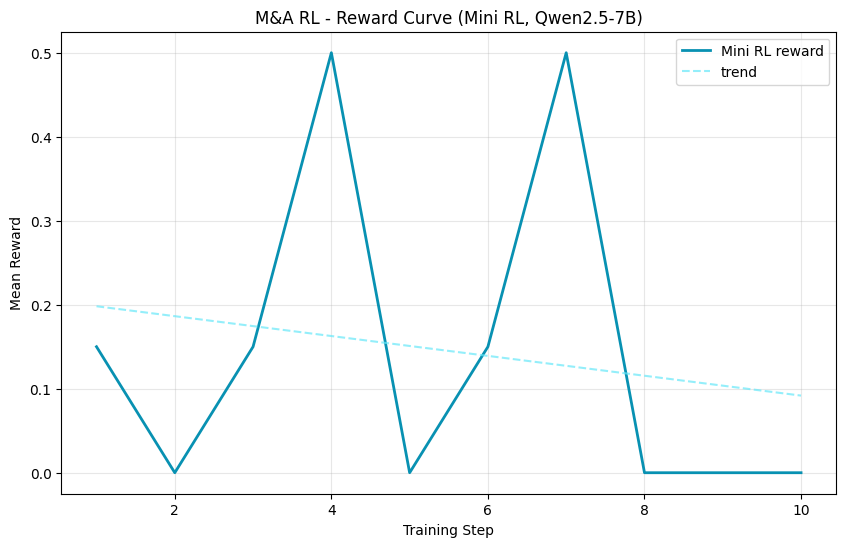

Saved reward_curve_mini.png


In [15]:
# Cell 11: reward_curve_mini.png (Phase 2 mini RL)
import matplotlib.pyplot as plt, numpy as np

fig_mini, ax_mini = plt.subplots(figsize=(10, 6))
if mini_reward_steps:
    ax_mini.plot(mini_reward_steps, mini_reward_vals, '#0891b2', lw=2, label='Mini RL reward')
    if len(mini_reward_steps) > 3:
        z = np.polyfit(mini_reward_steps, mini_reward_vals, 1)
        ax_mini.plot(mini_reward_steps, np.poly1d(z)(mini_reward_steps),
                     '--', color='#67e8f9', alpha=0.7, label='trend')
    ax_mini.legend()
ax_mini.set_xlabel('Training Step')
ax_mini.set_ylabel('Mean Reward')
ax_mini.set_title('M&A RL - Reward Curve (Mini RL, Qwen2.5-7B)')
ax_mini.grid(True, alpha=0.3)
fig_mini.savefig('reward_curve_mini.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved reward_curve_mini.png')

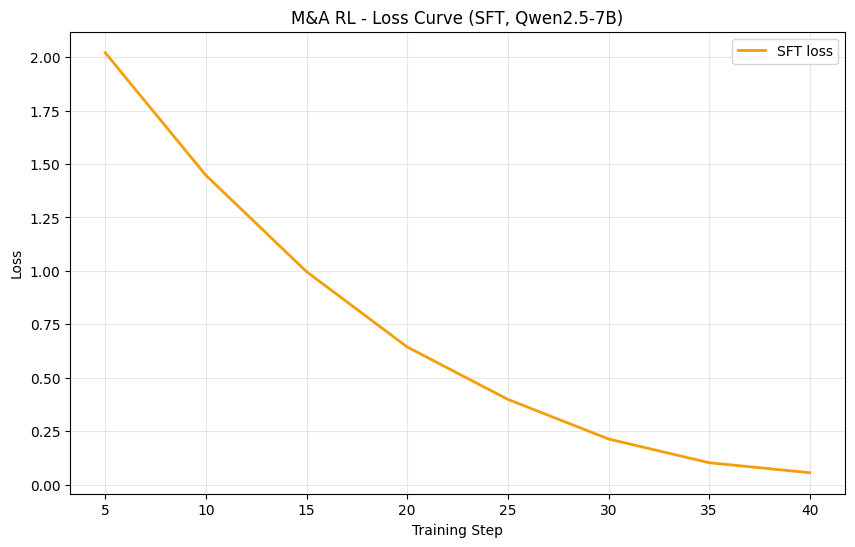

Saved sft_loss_curve.png


In [16]:
# Cell 12: sft_loss_curve.png (Phase 1 SFT)
import matplotlib.pyplot as plt

fig_sft, ax_sft = plt.subplots(figsize=(10, 6))
if sft_steps:
    ax_sft.plot(sft_steps, sft_loss_vals, '#f59e0b', lw=2, label='SFT loss')
    ax_sft.legend()
else:
    ax_sft.text(0.5, 0.5, 'No SFT loss data', transform=ax_sft.transAxes, ha='center')
ax_sft.set_xlabel('Training Step')
ax_sft.set_ylabel('Loss')
ax_sft.set_title('M&A RL - Loss Curve (SFT, Qwen2.5-7B)')
ax_sft.grid(True, alpha=0.3)
fig_sft.savefig('sft_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved sft_loss_curve.png')

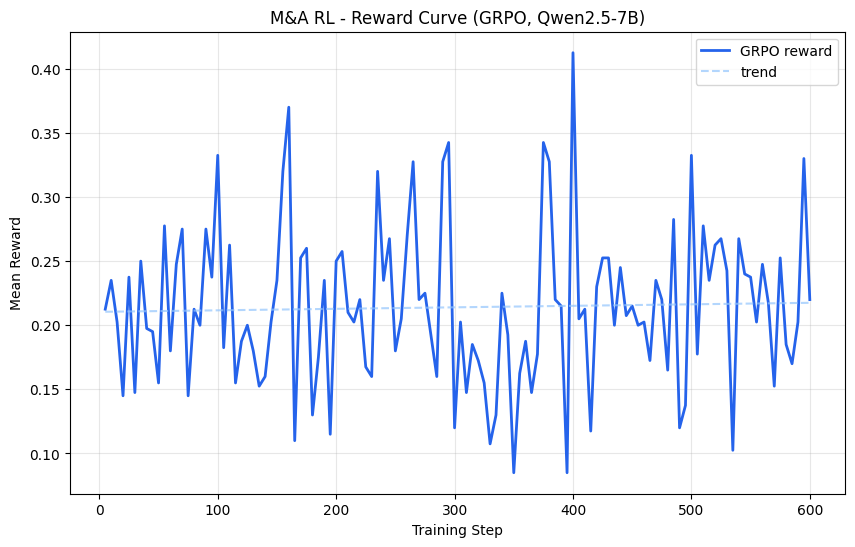

Saved reward_curve.png


In [ ]:
# Cell 13: reward_curve.png (Phase 3 heavy RL)
import matplotlib.pyplot as plt, numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
if reward_steps:
    ax.plot(reward_steps, reward_vals, '#2563eb', lw=2, label='GRPO reward')
    if len(reward_steps) > 3:
        z = np.polyfit(reward_steps, reward_vals, 1)
        ax.plot(reward_steps, np.poly1d(z)(reward_steps),
                '--', color='#93c5fd', alpha=0.7, label='trend')
    ax.legend()
    ax.set_ylabel('Mean Reward')
else:
    # Fallback to SFT loss
    ss = [x.get('step', i) for i, x in enumerate(sft_log) if 'loss' in x]
    sv = [x['loss'] for x in sft_log if 'loss' in x]
    ax.plot(ss, sv, '#2563eb', lw=2)
    ax.set_ylabel('SFT Loss (GRPO rewards not logged)')

ax.set_xlabel('Training Step')
ax.set_title('M&A RL - Reward Curve (GRPO, Qwen2.5-7B)')
ax.grid(True, alpha=0.3)
fig.savefig('reward_curve.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved reward_curve.png')

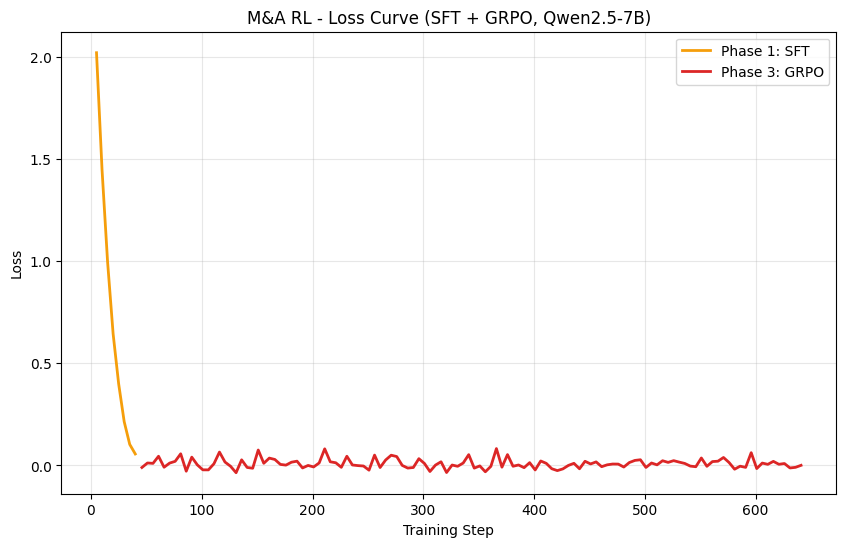

Saved loss_curve.png


In [18]:
# Cell 14: loss_curve.png (SFT + GRPO combined)
import matplotlib.pyplot as plt

fig2, ax2 = plt.subplots(figsize=(10, 6))
ss = [x.get('step', i) for i, x in enumerate(sft_log) if 'loss' in x]
sv = [x['loss'] for x in sft_log if 'loss' in x]
if ss:
    ax2.plot(ss, sv, '#f59e0b', lw=2, label='Phase 1: SFT')
if loss_steps:
    offset = (max(ss) + 1) if ss else 0
    ax2.plot([s + offset for s in loss_steps], loss_vals,
             '#dc2626', lw=2, label='Phase 3: GRPO')
if not ss and not loss_steps:
    ax2.text(0.5, 0.5, 'No loss data', transform=ax2.transAxes, ha='center')

ax2.set_xlabel('Training Step')
ax2.set_ylabel('Loss')
ax2.set_title('M&A RL - Loss Curve (SFT + GRPO, Qwen2.5-7B)')
ax2.grid(True, alpha=0.3)
if ss or loss_steps: ax2.legend()
fig2.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved loss_curve.png')

In [19]:
# Cell 15: Post-training output samples (hacking check)
FastLanguageModel.for_inference(model)
print('=== Post-Training Samples ===')
for i in range(5):
    obs = env.reset(seed=100+i)
    inputs = tokenizer(format_prompt(obs.task_prompt, obs.deal_excerpt),
                       return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=2048,
                             do_sample=True, temperature=0.7)
    text = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()
    obs2 = env.step(Action(agent_output=text, action_type='identify'))
    print(f'[{i+1}] reward={obs2.reward:.3f} | {text[:180]}')

Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


=== Post-Training Samples ===


/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/home/appuser/.local/lib/python3.10/site-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[1] reward=1.000 | {"clause_type": "non_compete", "reason": "The non-compete restriction is geographically broad (worldwide) and temporally long (36 months), covering all lines of business. This is f


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[2] reward=1.000 | {"clause_type": "indemnification", "reason": "The indemnification clause lacks any cap on liability, meaning the seller can be held responsible for unlimited losses. This is far ou


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[3] reward=1.000 | {"clause_type": "non_compete", "reason": "The non-compete restriction is geographically broad (worldwide) and temporally long (36 months post-deal), covering all lines of business.


Both `max_new_tokens` (=2048) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[4] reward=1.000 | {"clause_type": "change_of_control", "reason": "The change of control definition is broadly drafted to include any 20% threshold event, any merger, or sale of substantially all ass
[5] reward=0.300 | {"clause_type": "indemnification", "reason": "While the liability cap is set at 10% of the transaction value, the lack of specific indemnification triggers and mechanisms means the


In [20]:
# Cell 16: Save — MUST use save_pretrained_merged (not save_pretrained)
FastLanguageModel.for_training(model)
model.save_pretrained_merged('final_model', tokenizer, save_method='merged_16bit')
print('Saved: final_model/')

Unsloth: Restored added_tokens_decoder metadata in final_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /home/appuser/.cache/huggingface/hub


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 38.44it/s]


Checking cache directory for required files...
Cache check failed: model-00001-of-00004.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:11<00:00,  2.96s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:37<00:00,  9.32s/it]

Unsloth: Merge process complete. Saved to `/app/training/openenv_ma_analyzer/final_model`
Saved: final_model/


In [ ]:
# Cell 17: Commit training curves to repo
!git add reward_curve_mini.png sft_loss_curve.png reward_curve.png loss_curve.png
!git commit -m 'Add training curves (SFT+GRPO, Qwen2.5-7B, A100)'
#!git push

In [25]:
# Cell 18: Cleanup
server_proc.terminate()
print('Done! Artifacts: reward_curve_mini.png  sft_loss_curve.png  reward_curve.png  loss_curve.png  final_model/')

Done! Artifacts: reward_curve_mini.png  sft_loss_curve.png  reward_curve.png  loss_curve.png  final_model/
